# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

*Presentado por:*
- Shaiel Jiménez - 202323846
- Juan Esteban Triviño - 202315338

*ISIS2611 - Aprendizaje de Máquina / Sección 5*

*Profesor: Rubén Manrique*


**Contenido**

1. [Introducción](#introduccion)
2. [Carga de datos limpios](#datos)
3. [Actividad 1 — Regresión polinomial](#actividad1)
4. [Actividad 2 — Curvas de validación](#actividad2)
5. [Actividad 3 — Regresión regularizada (Ridge / Lasso)](#actividad3)
6. [Actividad 4 — Regresión polinomial regularizada](#actividad4)
7. [Actividad 5 — Comparación y selección del mejor modelo](#actividad5)
8. [Actividad 6 — Intervalos de confianza (bootstrapping)](#actividad6)
9. [Análisis de resultados](#analisis)
10. [Uso de herramientas de IA generativa](#iag)


## <a id="introduccion"></a> Introducción

En el [Laboratorio 1](../ISIS2611-Laboratorio1) se construyó un primer modelo de regresión
lineal para AlpesPlanck y se identificaron las variables más influyentes en la estimación de
la temperatura máxima del día siguiente (`temp_max_manana`). En este laboratorio se amplía
ese trabajo: se comparan enfoques de mayor complejidad (regresión polinomial y regularizada),
se estudia el trade-off sesgo-varianza mediante curvas de validación, se realiza búsqueda
sistemática de hiperparámetros con `GridSearchCV`, y se cuantifica la incertidumbre del
modelo final mediante bootstrapping.

**Nota metodológica.** El enunciado indica explícitamente que el énfasis de este laboratorio
no está en la exploración ni en la limpieza de los datos, sino en el modelado y la validación.
Por eso la limpieza (corrección de categorías, errores de escala, duplicados, outliers
imposibles e imputación sin fuga de datos) se reutiliza del Laboratorio 1 y se encapsula en
[`src/data_prep.py`](../src/data_prep.py); este notebook parte directamente de los conjuntos
`X_train`/`X_test` ya limpios.

> **TODO:** completar aquí, en 2-3 líneas, el resumen de decisiones metodológicas propias
> de este laboratorio (qué se comparó y por qué), una vez estén los resultados de las
> actividades 1 a 6.


## Configuración del entorno

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, validation_curve, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils import resample

sys.path.append(str(Path.cwd()))  # permite importar el paquete `src` desde la raíz del repo

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## <a id="datos"></a> Carga de datos limpios

Se reutiliza el pipeline de limpieza del Laboratorio 1 (`src/data_prep.py`), que aplica sobre
los datos crudos: corrección de categorías inconsistentes (`mes`, `estacion_anio`,
`sector_viento`), corrección de errores de escala (`presion_media`, `humedad_media`,
`humedad_min`), eliminación de duplicados y de outliers físicamente imposibles, eliminación de
filas sin variable objetivo, y separación train/test (75/25, `random_state=42`) **antes** de
imputar nulos (mediana para numéricas, moda para categóricas, ajustado solo con `X_train`) para
evitar fuga de datos.

In [3]:
from src.data_prep import cargar_datos_limpios

X_train, X_test, y_train, y_test = cargar_datos_limpios()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Nulos en X_train: {X_train.isna().sum().sum()} | Nulos en X_test: {X_test.isna().sum().sum()}")
X_train.head()


X_train: (1742, 26) | X_test: (581, 26)
Nulos en X_train: 0 | Nulos en X_test: 0


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
668,2011-01-01,990.4306,988.27,994.61,1.6986,87.9715,58.50,93.5,3.2908,2.50170,...,1.0125,-0.9174,-1.1860,232.2759,144.0,2011.0,1.0,invierno,enero,SO
205,2009-08-15,990.9322,988.86,992.65,1.4017,61.2281,33.60,95.2,21.8682,7.04088,...,-80.8750,-1.6241,-0.6097,200.5760,144.0,2009.0,227.0,invierno,julio,S
807,2011-06-02,1003.7751,1002.37,1005.08,0.7741,50.1300,33.96,70.3,11.7444,3.06400,...,2.4807,2.4297,1.5834,33.0913,144.0,2011.0,153.0,verano,diciembre,NE
2251,2015-10-26,996.8902,994.37,999.64,1.7672,88.1743,74.00,96.1,6.8894,6.72084,...,-56.4650,1.3131,1.0971,39.8797,144.0,2015.0,299.0,otono,septiembre,NE
557,2010-09-01,992.1408,991.32,993.17,0.3805,84.4896,73.20,93.5,4.7864,1.80630,...,1.1314,-0.5128,-1.4898,251.0061,144.0,2010.0,244.0,otono,septiembre,O


In [4]:
# Variables numéricas y categóricas usadas en los pipelines de este laboratorio
# (misma convención que el Laboratorio 1: 'fecha' queda fuera al no ser numérica ni
# estar en la lista de categóricas, y el ColumnTransformer la descarta por defecto).
categorical_features = ["mes", "estacion_anio", "sector_viento"]
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"Variables numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Variables categóricas ({len(categorical_features)}): {categorical_features}")


Variables numéricas (22): ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio']
Variables categóricas (3): ['mes', 'estacion_anio', 'sector_viento']


### Utilidades reutilizables

Estas funciones se usan a lo largo de todas las actividades (evaluación de métricas,
graficación de curvas de validación, extracción de coeficientes y bootstrapping), para no
repetir la misma lógica en cada modelo. Por convención, todos los pipelines de este notebook
deben nombrar sus pasos `"preprocesamiento"` y `"regresor"`.

In [5]:
resultados_modelos = []  # aquí se van acumulando las métricas de cada modelo (Actividad 5)


def evaluar_modelo(nombre, estimator, X_train, y_train, X_test, y_test, resultados=resultados_modelos):
    """Calcula RMSE, MAE y R² en train y test para un estimador ya ajustado
    y guarda el resultado en `resultados` (por defecto, `resultados_modelos`)."""
    y_train_pred = estimator.predict(X_train)
    y_test_pred = estimator.predict(X_test)

    metricas = {
        "modelo": nombre,
        "RMSE_train": mean_squared_error(y_train, y_train_pred) ** 0.5,
        "MAE_train": mean_absolute_error(y_train, y_train_pred),
        "R2_train": r2_score(y_train, y_train_pred),
        "RMSE_test": mean_squared_error(y_test, y_test_pred) ** 0.5,
        "MAE_test": mean_absolute_error(y_test, y_test_pred),
        "R2_test": r2_score(y_test, y_test_pred),
    }
    if resultados is not None:
        resultados.append(metricas)
    return metricas


def resumen_cv(grid, nombre):
    """Extrae el promedio y desviación estándar (en validación cruzada) del mejor
    conjunto de hiperparámetros encontrado por un GridSearchCV ya ajustado.
    Asume scoring='neg_root_mean_squared_error'."""
    idx = grid.best_index_
    return {
        "modelo": nombre,
        "mejores_hiperparametros": grid.best_params_,
        "RMSE_cv_mean": -grid.cv_results_["mean_test_score"][idx],
        "RMSE_cv_std": grid.cv_results_["std_test_score"][idx],
    }


def obtener_coeficientes(pipeline):
    """Devuelve un DataFrame con el nombre de cada variable transformada y su
    coeficiente, ordenado por magnitud absoluta descendente."""
    nombres = pipeline.named_steps["preprocesamiento"].get_feature_names_out()
    coefs = pipeline.named_steps["regresor"].coef_
    return (
        pd.DataFrame({"variable": nombres, "coeficiente": coefs})
        .assign(coef_abs=lambda d: d["coeficiente"].abs())
        .sort_values("coef_abs", ascending=False)
        .reset_index(drop=True)
    )


def graficar_curva_validacion(param_range, train_scores, test_scores, xlabel, titulo):
    """Grafica el score promedio ± 1 desviación estándar en train y en validación
    cruzada, en función de un hiperparámetro (p. ej. el grado del polinomio)."""
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    test_mean, test_std = test_scores.mean(axis=1), test_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(param_range, train_mean, label="Train", color="#4c72b0", marker="o")
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="#4c72b0")
    plt.plot(param_range, test_mean, label="Validación (CV)", color="#dd8452", marker="o")
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="#dd8452")
    plt.xlabel(xlabel)
    plt.ylabel("Score")
    plt.title(titulo)
    plt.legend()
    plt.tight_layout()
    plt.show()


def bootstrap_metricas(modelo, X_test, y_test, n_iteraciones=500, random_state=RANDOM_STATE):
    """Remuestrea (con reemplazo) el conjunto de test `n_iteraciones` veces y calcula
    RMSE, MAE y R² en cada remuestreo. Devuelve un DataFrame con una fila por remuestreo."""
    rng = np.random.RandomState(random_state)
    X_test = X_test.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    filas = []
    for _ in range(n_iteraciones):
        idx = rng.randint(0, len(X_test), len(X_test))
        X_boot, y_boot = X_test.iloc[idx], y_test.iloc[idx]
        y_pred = modelo.predict(X_boot)
        filas.append({
            "RMSE": mean_squared_error(y_boot, y_pred) ** 0.5,
            "MAE": mean_absolute_error(y_boot, y_pred),
            "R2": r2_score(y_boot, y_pred),
        })
    return pd.DataFrame(filas)


def intervalo_confianza(muestras, nivel=0.95):
    alpha = (1 - nivel) / 2
    return muestras.quantile(alpha), muestras.quantile(1 - alpha)


def graficar_distribucion_bootstrap(boot_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metrica in zip(axes, ["RMSE", "MAE", "R2"]):
        sns.histplot(boot_df[metrica], kde=True, ax=ax, color="#55a868")
        ax.axvline(boot_df[metrica].mean(), color="red", linestyle="--", label="media")
        ax.set_title(metrica)
        ax.legend()
    plt.tight_layout()
    plt.show()


## <a id="actividad1"></a> Actividad 1 — Regresión polinomial

**Qué pide el enunciado:** un pipeline con generación de características polinomiales +
regresión lineal, con búsqueda de hiperparámetros mediante `GridSearchCV` explorando el
**grado del polinomio** y **distintas estrategias de escalamiento**, reportando RMSE, MAE y
R², y analizando cómo cambia el desempeño (y el sobreajuste) al aumentar la complejidad.

**Decisiones de diseño.**

- **Grados explorados: 1 a 4.** El grado 1 es el caso base (una regresión lineal simple,
  equivalente a un modelo del Laboratorio 1). Con 22 variables numéricas, `PolynomialFeatures`
  genera 22, 275, 2299 y 14949 columnas para los grados 1 a 4 respectivamente. A partir de
  grado 3 ya hay más columnas que filas de entrenamiento por fold (~1393), así que se espera
  ver sobreajuste severo dentro de este mismo rango, en vez de tener que adivinar un rango más
  amplio.
- **Escaladores comparados: `StandardScaler` y `MinMaxScaler`.** Para una regresión lineal
  pura sin regularización, el escalador no cambia las predicciones (mínimos cuadrados
  encuentra el mismo hiperplano, solo cambia la escala de los coeficientes); lo que sí puede
  cambiar es la estabilidad numérica del ajuste cuando el número de columnas generadas es muy
  alto, por lo que conviene confirmarlo empíricamente y no darlo por sentado.
- **`cv=5`**: balance estándar entre varianza de la estimación (más folds) y costo
  computacional (menos folds).
- **`scoring="neg_root_mean_squared_error"`**: `GridSearchCV` siempre maximiza el score
  internamente, así que una métrica de error como RMSE debe pasarse en negativo para que
  "mejor" (score más alto) siga significando "menor error".

In [6]:
preprocesamiento_poly = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),  # valor inicial; el grid de abajo prueba ambas opciones
    ]), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

pipeline_poly = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_poly),
    ("regresor", LinearRegression()),
])

param_grid_poly = {
    "preprocesamiento__num__poly__degree": [1, 2, 3, 4],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()],
}

grid_poly = GridSearchCV(
    estimator=pipeline_poly,
    param_grid=param_grid_poly,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
)

grid_poly.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_poly.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_poly.best_score_:.3f}")


Mejores hiperparámetros: {'preprocesamiento__num__poly__degree': 1, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE promedio en validación cruzada: 6.967


In [7]:
# Resumen de la búsqueda: RMSE (train y validación) por grado y escalador
resumen_grid_poly = (
    pd.DataFrame(grid_poly.cv_results_)
    .loc[:, [
        "param_preprocesamiento__num__poly__degree",
        "param_preprocesamiento__num__scaler",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
    ]]
    .rename(columns={
        "param_preprocesamiento__num__poly__degree": "grado",
        "param_preprocesamiento__num__scaler": "escalador",
        "mean_train_score": "RMSE_cv_train",
        "mean_test_score": "RMSE_cv_val",
        "std_test_score": "RMSE_cv_val_std",
    })
    .assign(
        RMSE_cv_train=lambda d: -d["RMSE_cv_train"],
        RMSE_cv_val=lambda d: -d["RMSE_cv_val"],
    )
    .sort_values("grado")
    .reset_index(drop=True)
)
resumen_grid_poly


,grado,escalador,RMSE_cv_train,RMSE_cv_val,RMSE_cv_val_std
0,1,StandardScaler(),6.699574e+00,6.967166,0.433745
1,1,MinMaxScaler(),6.699574e+00,6.967166,0.433745
2,2,StandardScaler(),4.379621e+00,8.150377,1.426953
3,2,MinMaxScaler(),4.379621e+00,9.990556,4.884804
4,3,StandardScaler(),9.200306e-01,2090.227476,1422.795341
5,3,MinMaxScaler(),1.014478e+00,996.346442,606.850057
6,4,StandardScaler(),1.263073e-12,257.761535,113.958727
7,4,MinMaxScaler(),9.343679e-12,174.955292,69.563313


In [8]:
evaluar_modelo(
    "Regresión polinomial (GridSearchCV)", grid_poly.best_estimator_, X_train, y_train, X_test, y_test
)
pd.DataFrame(resultados_modelos).set_index("modelo")


,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
modelo,,,,,,
Regresión polinomial (GridSearchCV),6.727844,5.091492,0.479034,6.346607,5.094928,0.476326


**Análisis (Actividad 1).**

El mejor modelo según validación cruzada es el de **grado 1** (RMSE_cv ≈ 6.97), es decir, sin
ninguna expansión polinomial. En grado 1 ambos escaladores dan exactamente el mismo RMSE, tal
como se esperaba: escalar las variables no cambia el hiperplano que ajusta mínimos cuadrados
en una regresión lineal sin regularización.

A partir de grado 2 el desempeño ya empeora en validación cruzada (RMSE_cv sube a ~8.2-10.0)
aunque el error de entrenamiento baja (~4.4): la primera señal clara de sobreajuste, el modelo
empieza a ajustar ruido de train en vez de señal generalizable. En grado 3 el colapso es
total: el error de entrenamiento cae a ~0.9-1.0 (el modelo casi memoriza los datos — tiene
2299 columnas generadas contra ~1393 filas por fold de entrenamiento) pero el RMSE de
validación se dispara a 996-2090. En grado 4 (14949 columnas) el error de entrenamiento es
prácticamente 0 (ajuste perfecto / interpolación) y el error de validación, aunque algo menor
que en grado 3, sigue siendo enorme (175-258).

Este patrón es el trade-off sesgo-varianza de manual: al subir la complejidad, el sesgo baja
(el modelo ajusta cada vez mejor el training set) pero la varianza se dispara sin control,
porque no hay ningún mecanismo que limite la magnitud de los coeficientes. Esto motiva
directamente las Actividades 3 y 4, donde se prueba si Ridge/Lasso permiten usar grados más
altos sin este colapso.

En test, el modelo final (grado 1) obtiene RMSE ≈ 6.35, MAE ≈ 5.09, R² ≈ 0.48 — muy similar a
sus métricas de entrenamiento (RMSE ≈ 6.73, R² ≈ 0.48), sin señales de sobreajuste, consistente
con haber sido el ganador en validación cruzada.

## <a id="actividad2"></a> Actividad 2 — Curvas de validación

**Qué pide el enunciado:** a partir del modelo polinomial, generar curvas de validación
(error promedio ± variabilidad, vía validación cruzada) en función del grado del polinomio,
e identificar el punto en que se evidencia sobreajuste, interpretando en términos del
trade-off sesgo-varianza.

> **TODO:** justificar el rango de grados usado en la curva de validación (debería ser lo
> suficientemente amplio para mostrar tanto la zona de subajuste como la de sobreajuste) y la
> métrica de `scoring` usada.

In [9]:
# TODO: definir el rango de grados a evaluar en la curva de validación
rango_grados = [...]  # TODO, p. ej. range(1, 8)

# TODO: descomentar y ajustar. Nota: `validation_curve` reajusta el pipeline completo para
# cada valor de `param_range` y cada fold, por lo que puede tardar con grados altos.
# train_scores, test_scores = validation_curve(
#     estimator=pipeline_poly,          # usar el escalador ganador de la Actividad 1 fijo aquí
#     X=X_train, y=y_train,
#     param_name="preprocesamiento__num__poly__degree",
#     param_range=rango_grados,
#     cv=5,
#     scoring="neg_root_mean_squared_error",
#     n_jobs=-1,
# )
# graficar_curva_validacion(
#     rango_grados, -train_scores, -test_scores,
#     xlabel="Grado del polinomio", titulo="Curva de validación — RMSE vs. grado del polinomio",
# )


**Análisis (Actividad 2).**

> **TODO:** interpretar la curva: ¿en qué zona el modelo está subajustado (alto error en
> train y en validación)? ¿A partir de qué grado el error de train sigue bajando pero el de
> validación empieza a subir o a estancarse (sobreajuste)? Relacionar con el trade-off
> sesgo-varianza y con el grado óptimo encontrado en la Actividad 1.

## <a id="actividad3"></a> Actividad 3 — Regresión regularizada (Ridge / Lasso)

**Qué pide el enunciado:** pipelines con regularización L2 (Ridge) y L1 (Lasso), incluyendo el
parámetro de penalización (`alpha`) y distintas estrategias de escalamiento como
hiperparámetros en `GridSearchCV`; comparar contra un modelo **sin regularización**; analizar
el efecto de la penalización sobre generalización y magnitud de coeficientes; en Lasso,
examinar qué variables quedan en cero (selección automática de características).

> **TODO:** justificar el rango de valores de `alpha` explorado para cada modelo (Ridge y
> Lasso suelen requerir rangos distintos) y la estrategia de escalamiento considerada.

In [10]:
preprocesamiento_lineal = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),  # placeholder; el grid prueba otras opciones
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

# --- Modelo base: regresión lineal SIN regularización (referencia para el punto 3) ---
pipeline_base = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("regresor", LinearRegression()),
])
param_grid_base = {
    "preprocesamiento__num": [...],  # TODO: p. ej. [StandardScaler(), MinMaxScaler()]
}
grid_base = GridSearchCV(
    pipeline_base, param_grid_base, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True,
)

# --- Ridge (L2) ---
pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("regresor", Ridge(random_state=RANDOM_STATE)),
])
param_grid_ridge = {
    "preprocesamiento__num": [...],   # TODO
    "regresor__alpha": [...],          # TODO: p. ej. np.logspace(-3, 3, 13)
}
grid_ridge = GridSearchCV(
    pipeline_ridge, param_grid_ridge, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True,
)

# --- Lasso (L1) ---
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("regresor", Lasso(random_state=RANDOM_STATE, max_iter=10000)),
])
param_grid_lasso = {
    "preprocesamiento__num": [...],   # TODO
    "regresor__alpha": [...],          # TODO: p. ej. np.logspace(-3, 2, 13)
}
grid_lasso = GridSearchCV(
    pipeline_lasso, param_grid_lasso, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True,
)

# TODO: descomentar los tres ajustes
# grid_base.fit(X_train, y_train)
# grid_ridge.fit(X_train, y_train)
# grid_lasso.fit(X_train, y_train)


In [11]:
# TODO: descomentar una vez los tres GridSearchCV estén ajustados
# evaluar_modelo("Lineal sin regularización", grid_base.best_estimator_, X_train, y_train, X_test, y_test)
# evaluar_modelo("Ridge (L2)", grid_ridge.best_estimator_, X_train, y_train, X_test, y_test)
# evaluar_modelo("Lasso (L1)", grid_lasso.best_estimator_, X_train, y_train, X_test, y_test)
# pd.DataFrame(resultados_modelos).set_index("modelo")


In [12]:
# TODO: comparar la magnitud de los coeficientes de los tres modelos (descomentar):
# coefs_base = obtener_coeficientes(grid_base.best_estimator_)
# coefs_ridge = obtener_coeficientes(grid_ridge.best_estimator_)
# coefs_lasso = obtener_coeficientes(grid_lasso.best_estimator_)

# TODO: ¿qué variables quedaron exactamente en 0 en Lasso?
# variables_eliminadas_lasso = coefs_lasso[coefs_lasso["coeficiente"] == 0]
# variables_eliminadas_lasso


**Análisis (Actividad 3).**

> **TODO:** comparar el desempeño (RMSE/MAE/R²) de los tres modelos, describir cómo cambia
> la magnitud de los coeficientes con la penalización (Ridge los reduce pero no los anula,
> Lasso puede llevarlos exactamente a 0), listar qué variables elimina Lasso y qué implica eso
> en términos de selección automática de características e interpretabilidad para AlpesPlanck.

## <a id="actividad4"></a> Actividad 4 — Regresión polinomial regularizada

**Qué pide el enunciado:** combinar generación de características polinomiales con un modelo
regularizado (Ridge o Lasso), explorando grado del polinomio, `alpha` y escalamiento en la
misma búsqueda; evaluar con RMSE/MAE/R² por validación cruzada; discutir si la regularización
permite controlar el sobreajuste al aumentar la complejidad.

> **TODO:** decidir y justificar Ridge o Lasso para este modelo (o ambos, si el tiempo de
> cómputo lo permite) y el rango de grados/alphas a explorar. El enunciado advierte que esta
> búsqueda puede tardar bastante, así que conviene empezar con una grilla pequeña y ampliarla solo si
> el tiempo lo permite.

In [13]:
preprocesamiento_poly_reg = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),  # placeholder; el grid prueba otras opciones
    ]), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

# TODO: elegir Ridge o Lasso como regresor de este pipeline
pipeline_poly_reg = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_poly_reg),
    ("regresor", Ridge(random_state=RANDOM_STATE)),  # TODO: o Lasso(random_state=RANDOM_STATE, max_iter=10000)
])

param_grid_poly_reg = {
    "preprocesamiento__num__poly__degree": [...],  # TODO
    "preprocesamiento__num__scaler": [...],          # TODO
    "regresor__alpha": [...],                        # TODO
}

grid_poly_reg = GridSearchCV(
    pipeline_poly_reg, param_grid_poly_reg, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True,
)

# TODO: descomentar (grilla combinada; puede tardar bastante, ver nota del enunciado)
# grid_poly_reg.fit(X_train, y_train)
# print("Mejores hiperparámetros:", grid_poly_reg.best_params_)


In [14]:
# TODO: descomentar una vez `grid_poly_reg` esté ajustado
# evaluar_modelo("Polinomial regularizado", grid_poly_reg.best_estimator_, X_train, y_train, X_test, y_test)
# pd.DataFrame(resultados_modelos).set_index("modelo")


**Análisis (Actividad 4).**

> **TODO:** discutir si, a igual grado de complejidad, el modelo regularizado generaliza
> mejor que el polinomial sin regularizar de la Actividad 1 (comparar el gap train/test), y si
> la regularización permite usar grados más altos sin que el desempeño en test se deteriore.

## <a id="actividad5"></a> Actividad 5 — Comparación y selección del mejor modelo

**Qué pide el enunciado:** con base en los resultados de los puntos 1, 3 y 4, seleccionar el
mejor modelo considerando no solo el valor promedio de la métrica principal sino también su
estabilidad (desviación estándar en validación cruzada); reportar los mejores hiperparámetros
encontrados y argumentar la elección final.

In [15]:
# Tabla comparativa de RMSE/MAE/R² en train y test para todos los modelos evaluados
if resultados_modelos:
    tabla_comparativa = pd.DataFrame(resultados_modelos).set_index("modelo")
else:
    # Aún no se ha evaluado ningún modelo (celdas TODO pendientes más arriba)
    tabla_comparativa = pd.DataFrame(
        columns=["RMSE_train", "MAE_train", "R2_train", "RMSE_test", "MAE_test", "R2_test"]
    )
tabla_comparativa


,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
modelo,,,,,,
Regresión polinomial (GridSearchCV),6.727844,5.091492,0.479034,6.346607,5.094928,0.476326


In [16]:
# TODO: descomentar una vez los GridSearchCV relevantes (poly, base, ridge, lasso, poly_reg)
# estén ajustados, para comparar también la estabilidad en validación cruzada (media ± std).
# resumen_estabilidad = pd.DataFrame([
#     resumen_cv(grid_poly, "Regresión polinomial"),
#     resumen_cv(grid_base, "Lineal sin regularización"),
#     resumen_cv(grid_ridge, "Ridge (L2)"),
#     resumen_cv(grid_lasso, "Lasso (L1)"),
#     resumen_cv(grid_poly_reg, "Polinomial regularizado"),
# ]).set_index("modelo")
# resumen_estabilidad


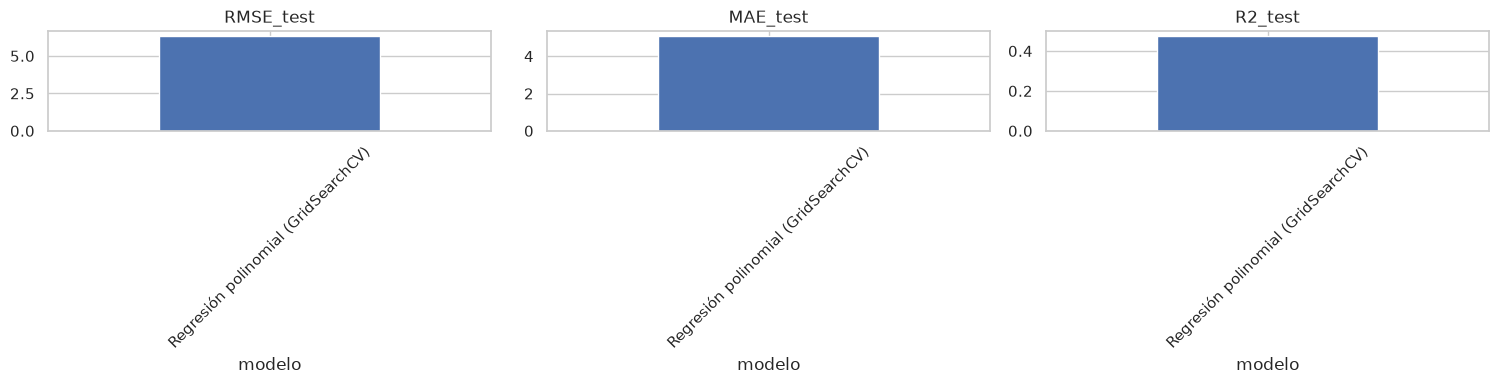

In [17]:
# Comparación visual de RMSE/MAE/R² (test) entre todos los modelos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metrica in zip(axes, ["RMSE_test", "MAE_test", "R2_test"]):
    if metrica in tabla_comparativa.columns and not tabla_comparativa.empty:
        tabla_comparativa[metrica].plot(kind="bar", ax=ax, color="#4c72b0")
    ax.set_title(metrica)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**Selección del mejor modelo.**

> **TODO:**
> - Reportar, en una tabla o lista, los mejores hiperparámetros encontrados para cada modelo
>   (`grid_XXX.best_params_`).
> - Elegir el modelo final considerando desempeño (RMSE/MAE/R² en test), estabilidad
>   (desviación estándar en CV) y complejidad/interpretabilidad, no solo el mejor promedio.
> - Justificar explícitamente la elección: ¿por qué ese modelo y no el de mejor métrica
>   promedio, si son distintos?

```python
# TODO: fijar aquí el modelo elegido, para usarlo en la Actividad 6
mejor_modelo = None  # TODO: p. ej. grid_ridge.best_estimator_
nombre_mejor_modelo = None  # TODO
```

In [18]:
# TODO: fijar aquí el modelo final elegido en la Actividad 5 (usado en la Actividad 6)
mejor_modelo = None  # TODO: p. ej. grid_ridge.best_estimator_
nombre_mejor_modelo = None  # TODO


## <a id="actividad6"></a> Actividad 6 — Intervalos de confianza (bootstrapping)

**Qué pide el enunciado:** usando el modelo seleccionado en la Actividad 5, aplicar
bootstrapping sobre el conjunto de test (al menos 500 remuestreos) para estimar intervalos de
confianza al 95% de RMSE, MAE y R²; graficar la distribución de los errores y discutir
estabilidad, variabilidad y confiabilidad de las predicciones.

In [19]:
# TODO: descomentar una vez `mejor_modelo` esté definido en la Actividad 5
# boot_df = bootstrap_metricas(mejor_modelo, X_test, y_test, n_iteraciones=500, random_state=RANDOM_STATE)
# boot_df.describe()


In [20]:
# TODO: descomentar una vez `boot_df` exista
# for metrica in ["RMSE", "MAE", "R2"]:
#     lower, upper = intervalo_confianza(boot_df[metrica])
#     print(f"{metrica}: media={boot_df[metrica].mean():.4f} | IC 95% = [{lower:.4f}, {upper:.4f}]")


In [21]:
# TODO: descomentar una vez `boot_df` exista
# graficar_distribucion_bootstrap(boot_df)


**Análisis (Actividad 6).**

> **TODO:** interpretar el ancho de los intervalos de confianza obtenidos (¿son estrechos y
> por tanto indican estabilidad, o amplios e indican alta variabilidad?), qué tan simétricas o
> sesgadas son las distribuciones de los errores, y qué implicaciones tiene esto para la
> confiabilidad de las predicciones que AlpesPlanck usaría en producción.

## <a id="analisis"></a> Análisis de resultados

### Análisis cuantitativo

- **¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**
  > _TODO_

- **¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?**
  > _TODO_

- **¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.**
  > _TODO_

- **Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**
  > _TODO_

- **¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**
  > _TODO_

- **¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?**
  > _TODO_

### Análisis cualitativo

- **¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**
  > _TODO_

- **¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?**
  > _TODO_

- **¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**
  > _TODO_

- **¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?**
  > _TODO_

- **¿Mayor precisión implica necesariamente mayor valor para la organización?**
  > _TODO_

- **¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.**
  > _TODO_

### Reflexión conceptual

- **¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?**
  > _TODO_

- **¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**
  > _TODO_

- **Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.**
  > _TODO_

## <a id="iag"></a> Uso de herramientas de IA generativa

### Entrada 1 — Montaje del esqueleto del laboratorio

**Declaración del uso.** Herramienta: Claude (Anthropic), vía Claude Code, con acceso directo
al repositorio (lectura del Laboratorio 1, creación de archivos, ejecución de comandos en el
entorno local). Tipo de uso: generación de un esqueleto inicial de proyecto y de notebook
(estructura de carpetas, pipeline de limpieza reutilizado del Laboratorio 1, definición de
funciones auxiliares de evaluación/graficación/bootstrapping, y celdas `TODO` para cada
actividad y pregunta de análisis del enunciado). No se usó para tomar decisiones de modelado
(rangos de hiperparámetros, elección de modelo final, interpretación de resultados): esas
quedaron explícitamente como `TODO` para el equipo.

**Prompt utilizado (resumido).** *"Ayúdame a montar el esqueleto del Laboratorio 2 de forma
profesional: revisa el enunciado del repositorio del curso, reutiliza lo que sea reutilizable
del Laboratorio 1 (mismo caso, mismos datos) y organiza el proyecto (estructura de carpetas,
requirements, notebook con las secciones de cada actividad y las preguntas de análisis ya
planteadas, sin resolver el modelado)."*

**Análisis crítico del resultado.**
- ¿Qué partes fueron correctas y útiles? La reutilización del pipeline de limpieza del
  Laboratorio 1 (sin fuga de datos) y las funciones auxiliares (evaluación de métricas,
  bootstrapping, extracción de coeficientes) son correctas y evitan reescribir lógica ya
  validada en el laboratorio anterior.
- ¿Qué decisiones técnicas quedaron pendientes de revisión propia? Los rangos de
  hiperparámetros sugeridos en los `TODO` (grados de polinomio, valores de `alpha`, folds de
  CV) son solo placeholders de ejemplo; el equipo debe definirlos con criterio propio y
  justificarlos, así como todas las interpretaciones de la sección de Análisis de resultados.

**Aportes propios del equipo.**
> _TODO: completar aquí, tras desarrollar las Actividades 1 a 6, qué se desarrolló, modificó o
> decidió por cuenta propia del equipo (rangos de hiperparámetros elegidos y por qué, modelo
> final seleccionado, interpretación de resultados, etc.)._

### Entrada 2 — Desarrollo de las actividades de modelado

> _TODO: documentar aquí (siguiendo el mismo formato: declaración del uso, prompts utilizados,
> análisis crítico y aportes propios) cualquier uso adicional de IA generativa durante el
> desarrollo de las Actividades 1 a 6 y de la sección de Análisis de resultados._

## Entregables y checklist final

- [ ] Notebook exportado también a `.html` (`jupyter nbconvert --to html sm.jimenezp1_j.trivinon.ipynb`).
- [ ] Todas las celdas ejecutadas y con sus salidas visibles (sin celdas `TODO` sin resolver).
- [ ] Tabla comparativa de modelos (Actividad 5) con los mejores hiperparámetros reportados.
- [ ] Intervalos de confianza (Actividad 6) calculados con al menos 500 remuestreos.
- [ ] Todas las preguntas de la sección "Análisis de resultados" respondidas.
- [ ] Sección "Uso de herramientas de IA generativa" completa (ambas entradas).
- [ ] Video explicativo grabado (máx. 3 minutos), orientado al ingeniero de ML que lidera el equipo de AlpesPlanck.
- [ ] Integrantes registrados en el grupo GL2 en BloqueNeón.

**Fecha límite: 14 de septiembre, 20:00** (penalización del 30% hasta el 15 de septiembre,
2:00 a.m.; después de esa hora, la entrega se califica con 0).